# Dataset Analysis
This is to identify low- and high-resource languages.

In [7]:
# Imports
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt
from helpers import *

### Extraction from FloRes-101
FloRes-101 is a paper proposing a NMT benchmark containing 101 languages across the entire spectrum from low-resource to high-resource.\
FloRes-200 is based on FloRes-101. Unfortunately the NLLB-200 training set was not published, thus we focus on the first 101 languages on which the FloRes-101 paper contains detailed metadata.

In [8]:
df = pd.read_csv("./flores_101_metadata.csv")
df["Bitex w/En"] = df["Bitex w/En"].apply(convert_to_number)
df["Mono Data"] = df["Mono Data"].apply(convert_to_number)
df.head()

,ISO 639-3,Language,Family,Subgrouping,Script,Bitex w/En,Mono Data
0,afr,Afrikaans,Indo-European,Germanic,Latin,570000.0,26100000.0
1,amh,Amharic,Afro-Asiatic,Semitic,Ge'ez,339000.0,3020000.0
2,ara,Arabic,Afro-Asiatic,Semitic,Arabic,25200000.0,126000000.0
3,arm,Armenian,Indo-European,Armenian,Armenian,977000.0,4100000.0
4,asm,Assamese,Indo-European,Indo-Aryan,Bengali,43700.0,738000.0


In [10]:
df["Language"]

0      Afrikaans
1        Amharic
2         Arabic
3       Armenian
4       Assamese
         ...    
96         Welsh
97         Wolof
98         Xhosa
99        Yoruba
100         Zulu
Name: Language, Length: 101, dtype: object

In [20]:
# Manual check
df[df["Language"] == "Swahili"]

,ISO 639-3,Language,Family,Subgrouping,Script,Bitex w/En,Mono Data
84,swh,Swahili,Atlantic-Congo,Bantu,Latin,349000.0,35800000.0


#### Resource Distributions

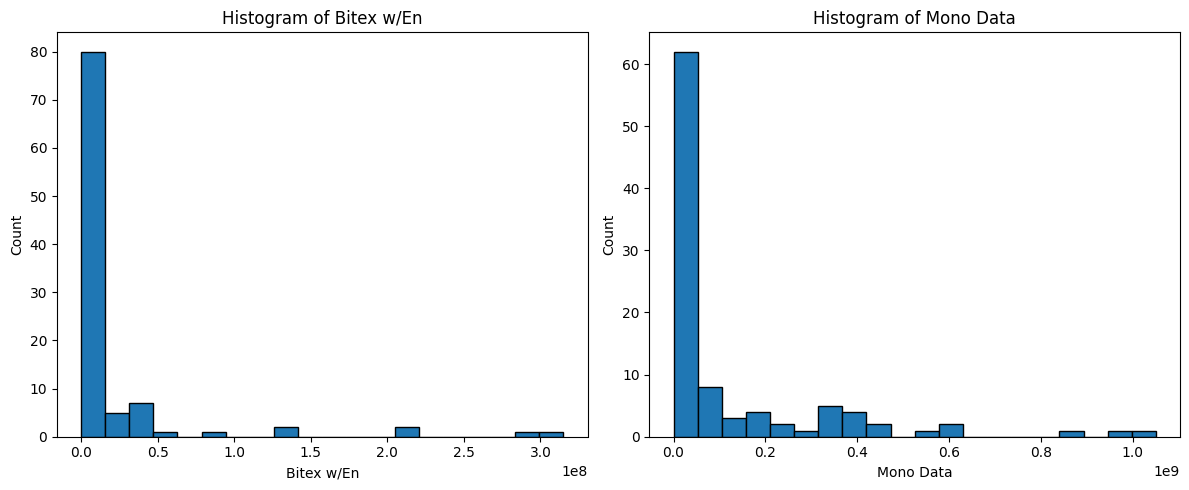

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df["Bitex w/En"], bins=20, edgecolor='black')
plt.title("Histogram of Bitex w/En")
plt.xlabel("Bitex w/En")
plt.ylabel("Count")

plt.subplot(1,2,2)
plt.hist(df["Mono Data"], bins=20, edgecolor='black')
plt.title("Histogram of Mono Data")
plt.xlabel("Mono Data")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

#### Top 10 Tables

In [5]:
# Lowest 10 and highest 10 for Bitex
print("\nLowest 10 by Bitex w/En:")
print(df.nsmallest(10, "Bitex w/En")[["Language", "Bitex w/En"]])

print("\nHighest 10 by Bitex w/En:")
print(df.nlargest(10, "Bitex w/En")[["Language", "Bitex w/En"]])

# Lowest 10 and highest 10 for Mono Data
print("\nLowest 10 by Mono Data:")
print(df.nsmallest(10, "Mono Data")[["Language", "Mono Data"]])

print("\nHighest 10 by Mono Data:")
print(df.nlargest(10, "Mono Data")[["Language", "Mono Data"]])


Lowest 10 by Bitex w/En:
          Language  Bitex w/En
42      Kabardianu      2460.0
55      Macedonian      3130.0
54   Luxembourgish      3410.0
67           Oriya      5000.0
63  Northern Sotho     13800.0
26           Ganda     14200.0
62          Nepali     19600.0
61       Mongolian     20800.0
51         Lingala     21100.0
78          Sindhi     21800.0

Highest 10 by Bitex w/En:
                   Language   Bitex w/En
83  Spanish (Latin America)  315000000.0
23                   French  289000000.0
28                   German  216000000.0
39                  Italian  216000000.0
72      Portuguese (Brazil)  137000000.0
75                  Russian  127000000.0
19                    Dutch   82400000.0
85                  Swedish   54800000.0
90                  Turkish   41200000.0
71                   Polish   40900000.0

Lowest 10 by Mono Data:
              Language  Mono Data
42          Kabardianu     1780.0
53                 Luo     2390.0
54       Luxembourgish     3

### Flores+
Flores+ is only an evaluation dataset in which all languages have the same number of sentences. Thus, it is not helpful for checking the resourcefulness of a lanugages in NLLB-200 pre-training.

In [ ]:
# Loading the dataset from local storage.
flores_ds = load_from_disk("../flores_plus/")
flores_ds

DatasetDict({
    dev: Dataset({
        features: ['id', 'iso_639_3', 'iso_15924', 'glottocode', 'text', 'url', 'domain', 'topic', 'has_image', 'has_hyperlink', 'last_updated'],
        num_rows: 219340
    })
    devtest: Dataset({
        features: ['id', 'iso_639_3', 'iso_15924', 'glottocode', 'text', 'url', 'domain', 'topic', 'has_image', 'has_hyperlink', 'last_updated'],
        num_rows: 216568
    })
})